# EEG-CLIP with Batch-wise Contrastive Learning

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import torchmetrics
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler
from typing import Any, Dict, List, Tuple, Union
import matplotlib.pyplot as plt

# For pre-trained text encoder
from sentence_transformers import SentenceTransformer

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MKL-DNN disabled for CPU compatibility")

PyTorch version: 2.6.0+cu124
CUDA available: True
MKL-DNN disabled for CPU compatibility


In [3]:
# ATCNet Model Implementation - Direct Embedding Output
# Attention-based Temporal Convolutional Network for EEG classification

class ATCNetDirectEmbedding(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 embedding_dim: int = 384,
                 num_windows: int = 3,
                 num_electrodes: int = 22,
                 conv_pool_size: int = 7,
                 F1: int = 16,
                 D: int = 2,
                 tcn_kernel_size: int = 4,
                 tcn_depth: int = 2,
                 chunk_size: int = 1125):
        super(ATCNetDirectEmbedding, self).__init__()
        self.in_channels = in_channels
        self.embedding_dim = embedding_dim
        self.num_windows = num_windows
        self.num_electrodes = num_electrodes
        self.pool_size = conv_pool_size
        self.F1 = F1
        self.D = D
        self.tcn_kernel_size = tcn_kernel_size
        self.tcn_depth = tcn_depth
        self.chunk_size = chunk_size
        F2 = F1*D

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, F1, (1, int(chunk_size/2+1)),
                      stride=1, padding='same', bias=False),
            nn.BatchNorm2d(F1, False),
            nn.Conv2d(F1, F2, (num_electrodes, 1), padding=0, groups=F1),
            nn.BatchNorm2d(F2, False),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout2d(0.1),
            nn.Conv2d(F2, F2, (1, 16), bias=False, padding='same'),
            nn.BatchNorm2d(F2, False),
            nn.ELU(),
            nn.AvgPool2d((1, self.pool_size)),
            nn.Dropout2d(0.1)
        )
        self.__build_model()

    def __build_model(self):
        with torch.no_grad():
            x = torch.zeros(2, self.in_channels,
                            self.num_electrodes, self.chunk_size)
            x = self.conv_block(x)
            x = x[:, :, -1, :]
            x = x.permute(0, 2, 1)
            self.__chan_dim, self.__embed_dim = x.shape[1:]
            self.win_len = self.__chan_dim - self.num_windows + 1

            for i in range(self.num_windows):
                st = i
                end = x.shape[1] - self.num_windows+i+1
                x2 = x[:, st:end, :]

                self.__add_msa(i)
                x2_ = self.get_submodule("msa"+str(i))(x2, x2, x2)[0]
                self.__add_msa_drop(i)
                x2_ = self.get_submodule("msa_drop"+str(i))(x2)
                x2 = torch.add(x2, x2_)

                for j in range(self.tcn_depth):
                    self.__add_tcn((i+1)*j, x2.shape[1])
                    out = self.get_submodule("tcn"+str((i+1)*j))(x2)
                    if x2.shape[1] != out.shape[1]:
                        self.__add_recov(i)
                        x2 = self.get_submodule("re"+str(i))(x2)
                    x2 = torch.add(x2, out)
                    x2 = nn.ELU()(x2)
                x2 = x2[:, -1, :]
                self.__dense_dim = x2.shape[-1]
                # Instead of outputting num_classes, output intermediate features
                self.__add_feature_projection(i)
                x2 = self.get_submodule("feature_proj"+str(i))(x2)
            
            # Calculate concatenated feature dimension
            self.__concat_feature_dim = x2.shape[-1] * self.num_windows
            
            # Add final projection to embedding dimension
            self.__add_final_projection()

    def __add_msa(self, index: int):
        self.add_module('msa'+str(index), nn.MultiheadAttention(
            embed_dim=self.__embed_dim,
            num_heads=2,
            batch_first=True))

    def __add_msa_drop(self, index):
        self.add_module('msa_drop'+str(index), nn.Dropout(0.3))

    def __add_tcn(self, index: int, num_electrodes: int):
        self.add_module('tcn'+str(index),
                        nn.Sequential(
            nn.Conv1d(num_electrodes, 32,
                      self.tcn_kernel_size, padding='same'),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Conv1d(32, 32, self.tcn_kernel_size, padding='same'),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.3))
        )

    def __add_recov(self, index: int):
        self.add_module('re'+str(index),
                        nn.Conv1d(self.win_len, 32, 4, padding='same'))

    def __add_feature_projection(self, index: int):
        """Project to intermediate feature dimension (not class labels)"""
        # Output larger feature dimension instead of num_classes
        intermediate_dim = 256
        self.add_module('feature_proj'+str(index),
                        nn.Sequential(
                            nn.Linear(self.__dense_dim, intermediate_dim),
                            nn.ReLU(),
                            nn.Dropout(0.1)
                        ))
    
    def __add_final_projection(self):
        """Final projection from concatenated features to embedding dimension"""
        self.final_projection = nn.Sequential(
            nn.Linear(self.__concat_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 768),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(768, self.embedding_dim)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x[:, :, -1, :]
        x = x.permute(0, 2, 1)

        window_features = []
        for i in range(self.num_windows):
            st = i
            end = x.shape[1] - self.num_windows+i+1
            x2 = x[:, st:end, :]
            x2_ = self.get_submodule("msa"+str(i))(x2, x2, x2)[0]
            x2_ = self.get_submodule("msa_drop"+str(i))(x2)
            x2 = torch.add(x2, x2_)

            for j in range(self.tcn_depth):
                out = self.get_submodule("tcn"+str((i+1)*j))(x2)
                if x2.shape[1] != out.shape[1]:
                    x2 = self.get_submodule("re"+str(i))(x2)
                x2 = torch.add(x2, out)
                x2 = nn.ELU()(x2)
            x2 = x2[:, -1, :]
            x2 = self.get_submodule("feature_proj"+str(i))(x2)
            window_features.append(x2)

        # Concatenate features from all windows
        concat_features = torch.cat(window_features, dim=1)
        
        # Project to final embedding dimension
        embeddings = self.final_projection(concat_features)
        
        # Normalize embeddings
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
        return embeddings

print("ATCNetDirectEmbedding model class defined successfully!")

ATCNetDirectEmbedding model class defined successfully!


In [4]:
# ============================================================================
# CAPTION TEMPLATES - For generating varied text descriptions
# ============================================================================

class CaptionGenerator:
    """
    Generates varied text captions for EEG trials.
    Each sample gets a unique caption based on its class.
    """
    
    def __init__(self, template_style='varied'):
        """
        Args:
            template_style: Choose template style
                - 'simple': Just action names (less variation)
                - 'varied': Multiple templates per class (more variation)
                - 'descriptive': Detailed descriptions
        """
        self.template_style = template_style
        
        # ====================================================================
        # EDIT THESE TEMPLATES FOR DIFFERENT CAPTION STYLES
        # ====================================================================
        
        # Simple: Just the action name (minimal variation)
        self.simple_templates = {
            0: ["left hand"],
            1: ["right hand"],
            2: ["foot"],
            3: ["rest"]
        }
        
        # Varied: Multiple templates per class
        self.varied_templates = {
            0: [
                "left hand movement",
                "moving left hand",
                "left hand motor imagery",
                "imagining left hand movement",
                "left hand grasping motion",
                "left hand activity"
            ],
            1: [
                "right hand movement",
                "moving right hand",
                "right hand motor imagery",
                "imagining right hand movement",
                "right hand grasping motion",
                "right hand activity"
            ],
            2: [
                "foot movement",
                "moving foot",
                "foot motor imagery",
                "imagining foot movement",
                "foot dorsiflexion",
                "foot activity"
            ],
            3: [
                "resting state",
                "no movement",
                "rest",
                "relaxed state",
                "no motor imagery",
                "baseline activity"
            ]
        }
        
        # Descriptive: Detailed descriptions
        self.descriptive_templates = {
            0: [
                "person performing left hand grasping motion",
                "brain activity during left hand motor imagery",
                "neural patterns of left hand movement",
                "EEG signals from left hand task",
                "cortical activity for left hand motion"
            ],
            1: [
                "person performing right hand grasping motion",
                "brain activity during right hand motor imagery",
                "neural patterns of right hand movement",
                "EEG signals from right hand task",
                "cortical activity for right hand motion"
            ],
            2: [
                "person performing foot dorsiflexion movement",
                "brain activity during foot motor imagery",
                "neural patterns of foot movement",
                "EEG signals from foot task",
                "cortical activity for foot motion"
            ],
            3: [
                "person in relaxed resting state",
                "brain activity during rest",
                "baseline neural patterns",
                "EEG signals during rest",
                "cortical activity at rest"
            ]
        }
        
        # Select templates based on style
        self.templates = self._get_templates()
        
        print(f"\n{'='*80}")
        print(f"CAPTION GENERATOR - Style: '{template_style}'")
        print(f"{'='*80}")
        for class_idx, templates in self.templates.items():
            class_names = ["left hand", "right hand", "foot", "rest"]
            print(f"  Class {class_idx} ({class_names[class_idx]}): {len(templates)} templates")
            for template in templates:
                print(f"    - '{template}'")
        print(f"{'='*80}\n")
    
    def _get_templates(self):
        if self.template_style == 'simple':
            return self.simple_templates
        elif self.template_style == 'varied':
            return self.varied_templates
        elif self.template_style == 'descriptive':
            return self.descriptive_templates
        else:
            return self.varied_templates
    
    def generate_caption(self, class_idx, variant_idx=0):
        """Generate caption for a specific class and variant"""
        templates = self.templates[class_idx]
        return templates[variant_idx % len(templates)]
    
    def generate_batch_captions(self, labels):
        """
        Generate captions for a batch of labels.
        Uses different variants to create unique captions.
        """
        captions = []
        # Use numpy random for variant selection to add diversity
        for i, label in enumerate(labels):
            variant_idx = np.random.randint(0, len(self.templates[int(label)]))
            captions.append(self.generate_caption(int(label), variant_idx))
        return captions


# Test caption generator
print("\nTesting caption generator:\n")
generator = CaptionGenerator(template_style='varied')
test_labels = [0, 1, 2, 3, 0, 1]
test_captions = generator.generate_batch_captions(test_labels)
print("\nExample batch captions:")
for label, caption in zip(test_labels, test_captions):
    print(f"  Label {label}: '{caption}'")

print("\nCaptionGenerator class defined successfully!")


Testing caption generator:


CAPTION GENERATOR - Style: 'varied'
  Class 0 (left hand): 6 templates
    - 'left hand movement'
    - 'moving left hand'
    - 'left hand motor imagery'
    - 'imagining left hand movement'
    - 'left hand grasping motion'
    - 'left hand activity'
  Class 1 (right hand): 6 templates
    - 'right hand movement'
    - 'moving right hand'
    - 'right hand motor imagery'
    - 'imagining right hand movement'
    - 'right hand grasping motion'
    - 'right hand activity'
  Class 2 (foot): 6 templates
    - 'foot movement'
    - 'moving foot'
    - 'foot motor imagery'
    - 'imagining foot movement'
    - 'foot dorsiflexion'
    - 'foot activity'
  Class 3 (rest): 6 templates
    - 'resting state'
    - 'no movement'
    - 'rest'
    - 'relaxed state'
    - 'no motor imagery'
    - 'baseline activity'


Example batch captions:
  Label 0: 'left hand activity'
  Label 1: 'moving right hand'
  Label 2: 'foot dorsiflexion'
  Label 3: 'resting state'
  Label 0

In [5]:
# Multi-Subject ECoG/EEG Dataset - Returns (eeg_data, label) pairs
# Captions are generated on-the-fly during training

class MultiSubjectECoGDataset(Dataset):
    def __init__(self, 
                 file_list, 
                 freq_band=(1, 100), 
                 remove_bad=True, 
                 scale=True, 
                 transform=None, 
                 time_range=None):
        """
        PyTorch Dataset for loading multi-subject ECoG/EEG data.
        Returns (eeg_data, class_label) pairs.
        Text captions are generated dynamically during training.
        """
        self.transform = transform
        self.data = []
        self.labels = []
        self.scale = scale
        self.remove_bad = remove_bad
        self.freq_band = freq_band
        self.time_range = time_range

        for file in file_list:
            print(f'Loading and processing {file}')
            self._load_subject_data(file)

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"Loaded {len(self.data)} trials from {len(file_list)} subjects.")
        print(f"Data shape: {self.data.shape}")
        
        # Print class distribution
        unique, counts = np.unique(self.labels, return_counts=True)
        print(f"\nClass distribution:")
        class_names = ["left hand", "right hand", "foot", "rest"]
        for cls, count in zip(unique, counts):
            print(f"  Class {cls} ({class_names[cls]}): {count} samples")

    def _load_subject_data(self, file_path):
        # Load raw data
        raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)
        if self.remove_bad:
            raw.pick_types(ecog=True, eeg=True, exclude='bads')
        
        # Apply bandpass filter
        if self.freq_band:
            raw.filter(self.freq_band[0], self.freq_band[1], fir_design='firwin', verbose=False)

        # Get events and labels
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        print(f"  Found {len(events)} events")

        # Epoching
        if self.time_range:
            tmin, tmax = self.time_range
        else:
            tmin, tmax = 0, 4

        epochs = mne.Epochs(
            raw, events, event_id=event_id,
            tmin=tmin, tmax=tmax,
            baseline=None, preload=True, verbose=False
        )

        X = epochs.get_data()
        y = epochs.events[:, -1]

        # Scaling
        if self.scale:
            for ch in range(X.shape[1]):
                scaler = StandardScaler()
                X[:, ch, :] = scaler.fit_transform(X[:, ch, :])
        
        # Save data and labels
        for trial, label in zip(X, y):
            self.data.append(trial)
            # Convert to 0-indexed (0=left, 1=right, 2=foot, 3=rest)
            self.labels.append(int(label) - 1)
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sample = self.data[index]
        label = self.labels[index]

        # Convert to tensor
        sample = torch.from_numpy(sample).float().unsqueeze(0)
        label = torch.tensor(label).long()

        if self.transform:
            sample = self.transform(sample)

        return sample, label

print("MultiSubjectECoGDataset class defined successfully!")

MultiSubjectECoGDataset class defined successfully!


In [6]:
# Frozen Text Encoder

class FrozenTextEncoder(nn.Module):
    """
    Completely FROZEN pre-trained text encoder.
    Outputs native 384-dimensional embeddings.
    """
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        super(FrozenTextEncoder, self).__init__()
        
        print(f"\nLoading FROZEN text encoder: {model_name}")
        self.encoder = SentenceTransformer(model_name)
        
        # FREEZE all parameters
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        self.encoder.eval()
        
        if 'mpnet' in model_name:
            self.output_dim = 768
        else:
            self.output_dim = 384
        
        print(f"✓ Text encoder FROZEN")
        print(f"✓ Output dimension: {self.output_dim}")
        
    def forward(self, texts):
        with torch.no_grad():
            embeddings = self.encoder.encode(
                texts,
                convert_to_tensor=True,
                show_progress_bar=False,
                normalize_embeddings=True
            )
        return embeddings
    
    def train(self, mode=True):
        return self

print("FrozenTextEncoder defined successfully!")

FrozenTextEncoder defined successfully!


In [7]:
# ============================================================================
# EEG-CLIP Model with Batch-wise Contrastive Learning
# ============================================================================

class EEG_CLIP_Batch(nn.Module):
    """
    Standard CLIP model for EEG.
    
    Key Features:
    - Compares each EEG against ALL text captions in batch
    - Symmetric contrastive loss (EEG→Text + Text→EEG)
    - Text embeddings computed dynamically per batch
    - ATCNet outputs embeddings DIRECTLY (no bottleneck)
    """
    def __init__(self, 
                 num_electrodes=50,
                 chunk_size=1001,
                 embedding_dim=384,
                 temperature=0.07,
                 text_model='all-MiniLM-L6-v2'):
        super(EEG_CLIP_Batch, self).__init__()
        
        # EEG encoder - outputs embeddings directly
        self.eeg_encoder = ATCNetDirectEmbedding(
            in_channels=1,
            embedding_dim=embedding_dim,
            num_electrodes=num_electrodes,
            chunk_size=chunk_size
        )
        
        # Frozen text encoder
        self.text_encoder = FrozenTextEncoder(model_name=text_model)
        
        # Learnable temperature parameter
        self.temperature = nn.Parameter(torch.tensor(temperature))
        
        print("\n" + "="*80)
        print("EEG-CLIP Batch-wise Contrastive Model")
        print("="*80)
        print(f"Architecture:")
        print(f"  EEG Encoder: ATCNet (Direct) → {embedding_dim} dim (TRAINABLE)")
        print(f"  Text Encoder: {text_model} → {embedding_dim} dim (FROZEN)")
        print(f"  Temperature: {temperature} (learnable)")
        print(f"\nTraining Strategy:")
        print(f"  Each EEG compared against ALL batch text captions")
        print(f"  Symmetric loss: EEG→Text + Text→EEG")
        print(f"  Random baseline: 1/batch_size (e.g., 3.125% for batch=32)")
        print("="*80)
        
    def forward(self, eeg_data, text_captions):
        """
        Forward pass.
        
        Args:
            eeg_data: (batch_size, 1, num_electrodes, time_points)
            text_captions: List of strings (batch_size captions)
            
        Returns:
            logits_eeg_to_text: (batch_size, batch_size) - EEG→Text similarities
            logits_text_to_eeg: (batch_size, batch_size) - Text→EEG similarities
        """
        # Encode EEG
        eeg_embeddings = self.eeg_encoder(eeg_data)  # (batch_size, 384)
        
        # Encode text
        text_embeddings = self.text_encoder(text_captions)  # (batch_size, 384)
        
        # Compute similarity matrix
        # (batch_size, 384) @ (384, batch_size) = (batch_size, batch_size)
        logits = torch.matmul(eeg_embeddings, text_embeddings.t()) / self.temperature
        
        # For symmetric loss, we need both directions
        logits_eeg_to_text = logits  # Each row: one EEG vs all texts
        logits_text_to_eeg = logits.t()  # Each row: one text vs all EEGs
        
        return logits_eeg_to_text, logits_text_to_eeg

print("\nEEG-CLIP Batch model defined successfully!")


EEG-CLIP Batch model defined successfully!


In [8]:
# ============================================================================
# Training Module with Batch-wise Contrastive Loss
# ============================================================================

class EEGCLIPTrainer(pl.LightningModule):
    def __init__(self, 
                 num_electrodes=50,
                 chunk_size=1001,
                 embedding_dim=384,
                 lr=3e-4,
                 weight_decay=1e-4,
                 temperature=0.07,
                 text_model='all-MiniLM-L6-v2',
                 template_style='varied'):
        super().__init__()
        
        self.save_hyperparameters()
        
        # Create caption generator
        self.caption_generator = CaptionGenerator(template_style=template_style)
        
        # Initialize model
        self.model = EEG_CLIP_Batch(
            num_electrodes=num_electrodes,
            chunk_size=chunk_size,
            embedding_dim=embedding_dim,
            temperature=temperature,
            text_model=text_model
        )
        
        # Loss: Cross-entropy for contrastive learning
        self.loss_fn = nn.CrossEntropyLoss()
        
        # Metrics for retrieval accuracy
        # Note: We track top-1 accuracy (correct match in batch)
        self.train_acc_eeg = torchmetrics.Accuracy(task='multiclass', num_classes=32)  # Will be adjusted dynamically
        self.train_acc_text = torchmetrics.Accuracy(task='multiclass', num_classes=32)
        self.val_acc_eeg = torchmetrics.Accuracy(task='multiclass', num_classes=32)
        self.val_acc_text = torchmetrics.Accuracy(task='multiclass', num_classes=32)
        
        # Also track classification accuracy (for 4 classes)
        self.val_class_acc = torchmetrics.Accuracy(task='multiclass', num_classes=4)
        self.test_class_acc = torchmetrics.Accuracy(task='multiclass', num_classes=4)
        
        # Confusion matrix for 4-class classification
        self.val_confusion = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=4)
        self.test_confusion = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=4)
        
    def forward(self, eeg_data, text_captions):
        return self.model(eeg_data, text_captions)
    
    def training_step(self, batch, batch_idx):
        eeg_data, labels = batch
        batch_size = eeg_data.size(0)
        
        # Generate captions for this batch
        text_captions = self.caption_generator.generate_batch_captions(labels.cpu().numpy())
        
        # Forward pass: get similarity matrices
        logits_eeg_to_text, logits_text_to_eeg = self(eeg_data, text_captions)
        
        # Create labels: diagonal indices (each sample matches itself)
        targets = torch.arange(batch_size, device=eeg_data.device)
        
        # Symmetric contrastive loss
        loss_eeg = self.loss_fn(logits_eeg_to_text, targets)  # EEG → Text
        loss_text = self.loss_fn(logits_text_to_eeg, targets)  # Text → EEG
        loss = (loss_eeg + loss_text) / 2
        
        # Calculate retrieval accuracy
        preds_eeg = torch.argmax(logits_eeg_to_text, dim=1)
        preds_text = torch.argmax(logits_text_to_eeg, dim=1)
        
        acc_eeg = (preds_eeg == targets).float().mean()
        acc_text = (preds_text == targets).float().mean()
        acc = (acc_eeg + acc_text) / 2
        
        # Log metrics
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc_eeg', acc_eeg, on_step=False, on_epoch=True)
        self.log('train_acc_text', acc_text, on_step=False, on_epoch=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        eeg_data, labels = batch
        batch_size = eeg_data.size(0)
        
        # Generate captions
        text_captions = self.caption_generator.generate_batch_captions(labels.cpu().numpy())
        
        # Forward pass
        logits_eeg_to_text, logits_text_to_eeg = self(eeg_data, text_captions)
        
        # Retrieval loss and accuracy
        targets = torch.arange(batch_size, device=eeg_data.device)
        loss_eeg = self.loss_fn(logits_eeg_to_text, targets)
        loss_text = self.loss_fn(logits_text_to_eeg, targets)
        loss = (loss_eeg + loss_text) / 2
        
        preds_eeg = torch.argmax(logits_eeg_to_text, dim=1)
        preds_text = torch.argmax(logits_text_to_eeg, dim=1)
        
        acc_eeg = (preds_eeg == targets).float().mean()
        acc_text = (preds_text == targets).float().mean()
        acc = (acc_eeg + acc_text) / 2
        
        # Classification accuracy: which class has highest similarity?
        # Get embeddings for all 4 class templates
        class_templates = [
            self.caption_generator.generate_caption(0, 0),
            self.caption_generator.generate_caption(1, 0),
            self.caption_generator.generate_caption(2, 0),
            self.caption_generator.generate_caption(3, 0)
        ]
        eeg_emb = self.model.eeg_encoder(eeg_data)
        class_emb = self.model.text_encoder(class_templates)
        class_logits = torch.matmul(eeg_emb, class_emb.t())
        class_preds = torch.argmax(class_logits, dim=1)
        
        class_acc = self.val_class_acc(class_preds, labels)
        self.val_confusion.update(class_preds, labels)
        
        # Log metrics
        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        self.log('val_acc_retrieval', acc, prog_bar=True, on_epoch=True)
        self.log('val_acc_eeg', acc_eeg, on_epoch=True)
        self.log('val_acc_text', acc_text, on_epoch=True)
        self.log('val_acc_class', class_acc, prog_bar=True, on_epoch=True)
        
        return loss
    
    def test_step(self, batch, batch_idx):
        eeg_data, labels = batch
        
        # Classification using class templates
        class_templates = [
            self.caption_generator.generate_caption(0, 0),
            self.caption_generator.generate_caption(1, 0),
            self.caption_generator.generate_caption(2, 0),
            self.caption_generator.generate_caption(3, 0)
        ]
        eeg_emb = self.model.eeg_encoder(eeg_data)
        class_emb = self.model.text_encoder(class_templates)
        class_logits = torch.matmul(eeg_emb, class_emb.t())
        class_preds = torch.argmax(class_logits, dim=1)
        
        acc = self.test_class_acc(class_preds, labels)
        self.test_confusion.update(class_preds, labels)
        
        self.log('test_acc', acc, on_epoch=True)
        
    def configure_optimizers(self):
        # Only optimize EEG encoder + temperature
        optimizer = torch.optim.AdamW(
            [
                {'params': self.model.eeg_encoder.parameters()},
                {'params': [self.model.temperature]}
            ],
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )
        
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=100,
            eta_min=1e-6
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch'
            }
        }

print("EEGCLIPTrainer defined successfully!")

EEGCLIPTrainer defined successfully!


In [9]:
# ============================================================================
# DATA LOADING
# ============================================================================

# Dataset configuration
DATA_PREFIX = "/kaggle/input/high-gamma-dataset-fif/"

train_file_list = [
    f"{DATA_PREFIX}Subject 2/0/0-raw.fif",
    f"{DATA_PREFIX}Subject 2/1/1-raw.fif",
    f"{DATA_PREFIX}Subject 3/0/0-raw.fif",
    f"{DATA_PREFIX}Subject 3/1/1-raw.fif",
]

val_file_list = [
    f"{DATA_PREFIX}Subject 1/1/1-raw.fif",
    f"{DATA_PREFIX}Subject 1/0/0-raw.fif",
]

# ============================================================================
# TEMPLATE STYLE SELECTION
# ============================================================================
# Options: 'simple', 'varied', 'descriptive'
TEMPLATE_STYLE = 'varied'  # <-- EDIT THIS

print(f"\n{'='*80}")
print(f"Creating datasets")
print(f"Template style: '{TEMPLATE_STYLE}'")
print(f"{'='*80}\n")

# Create datasets
train_dataset = MultiSubjectECoGDataset(
    file_list=train_file_list,
    freq_band=(1, 100),
    time_range=(0.0, 4.0),
    remove_bad=True,
    scale=True
)

val_dataset = MultiSubjectECoGDataset(
    file_list=val_file_list,
    freq_band=(1, 100),
    time_range=(0.0, 4.0),
    remove_bad=True,
    scale=True
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Check a batch
for eeg_data, labels in train_loader:
    print(f"\nBatch shape:")
    print(f"  EEG data: {eeg_data.shape}")
    print(f"  Labels: {labels.shape}")
    print(f"  Label values: {labels[:10]}")
    break

print(f"\n{'='*80}")
print("Dataset loading complete!")
print(f"{'='*80}")


Creating datasets
Template style: 'varied'

Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 2/0/0-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 813 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 2/1/1-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 160 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 3/0/0-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 880 events
Loading and processing /kaggle/input/high-gamma-dataset-fif/Subject 3/1/1-raw.fif
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
  Found 160 events
Loaded 2013 trials from 4 subjects.
Data shape: (2013, 50, 1001)

Class distribution:
  Class 0 (left hand): 504 samples
  Class 1 (right hand): 502 samples
  Class 2 (foot): 503 samples
  Class 3 (rest): 504 samples
Loading and processing /ka

In [11]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # recommended in notebooks

In [12]:
# ============================================================================
# TRAINING
# ============================================================================

# Model configuration
model = EEGCLIPTrainer(
    num_electrodes=50,
    chunk_size=1001,
    embedding_dim=384,
    lr=3e-4,
    weight_decay=1e-4,
    temperature=0.07,
    text_model='all-MiniLM-L6-v2',
    template_style=TEMPLATE_STYLE
)

# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print("="*80)

# Trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=1,
)

print("\nStarting training...")
print(f"Expected retrieval baseline: ~3.125% (1/32 for batch_size=32)")
print(f"Expected classification baseline: 25% (1/4 classes)")
print(f"Good retrieval performance: 40-60%")
print(f"Good classification performance: 60-80%")
print(f"Excellent classification performance: >80%\n")

# Train
trainer.fit(model, train_loader, val_loader)

# Test
trainer.test(model, val_loader)

print("\nTraining complete!")


CAPTION GENERATOR - Style: 'varied'
  Class 0 (left hand): 6 templates
    - 'left hand movement'
    - 'moving left hand'
    - 'left hand motor imagery'
    - 'imagining left hand movement'
    - 'left hand grasping motion'
    - 'left hand activity'
  Class 1 (right hand): 6 templates
    - 'right hand movement'
    - 'moving right hand'
    - 'right hand motor imagery'
    - 'imagining right hand movement'
    - 'right hand grasping motion'
    - 'right hand activity'
  Class 2 (foot): 6 templates
    - 'foot movement'
    - 'moving foot'
    - 'foot motor imagery'
    - 'imagining foot movement'
    - 'foot dorsiflexion'
    - 'foot activity'
  Class 3 (rest): 6 templates
    - 'resting state'
    - 'no movement'
    - 'rest'
    - 'relaxed state'
    - 'no motor imagery'
    - 'baseline activity'


Loading FROZEN text encoder: all-MiniLM-L6-v2


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type                      | Params | Mode 
---------------------------------------------------------------------
0 | model          | EEG_CLIP_Batch            | 23.9 M | train
1 | loss_fn        | CrossEntropyLoss          | 0      | train
2 | train_acc_eeg  | MulticlassAccuracy        | 0      | train
3 | train_acc_text | MulticlassAccuracy        | 0      | train
4 | val_acc_eeg    | MulticlassAccuracy        | 0      | train
5 | val_acc_text   | MulticlassAccuracy        | 0      | train
6 | val_class_acc  | MulticlassAccuracy        | 0      | train
7 | test_class_acc | MulticlassAccuracy        | 0    

✓ Text encoder FROZEN
✓ Output dimension: 384

EEG-CLIP Batch-wise Contrastive Model
Architecture:
  EEG Encoder: ATCNet (Direct) → 384 dim (TRAINABLE)
  Text Encoder: all-MiniLM-L6-v2 → 384 dim (FROZEN)
  Temperature: 0.07 (learnable)

Training Strategy:
  Each EEG compared against ALL batch text captions
  Symmetric loss: EEG→Text + Text→EEG
  Random baseline: 1/batch_size (e.g., 3.125% for batch=32)

MODEL SUMMARY
Total parameters: 23,897,649
Trainable parameters: 1,184,433
Frozen parameters: 22,713,216

Starting training...
Expected retrieval baseline: ~3.125% (1/32 for batch_size=32)
Expected classification baseline: 25% (1/4 classes)
Good retrieval performance: 40-60%
Good classification performance: 60-80%
Excellent classification performance: >80%



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7958333492279053     │
└───────────────────────────┴───────────────────────────┘


Training complete!



EVALUATION RESULTS

Generating confusion matrix...


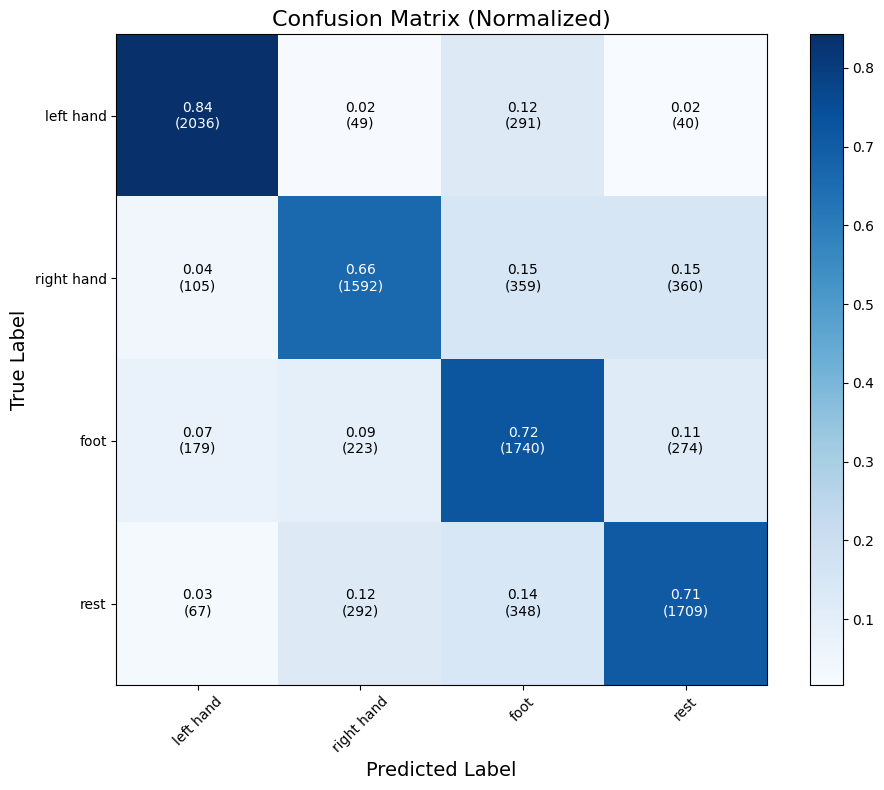


PER-CLASS ACCURACY
left hand      : 84.27% (2036/2416)
right hand     : 65.89% (1592/2416)
foot           : 72.02% (1740/2416)
rest           : 70.74% (1709/2416)
Overall        : 73.23% (7077/9664)

Generating embedding visualization...

Applying t-SNE...


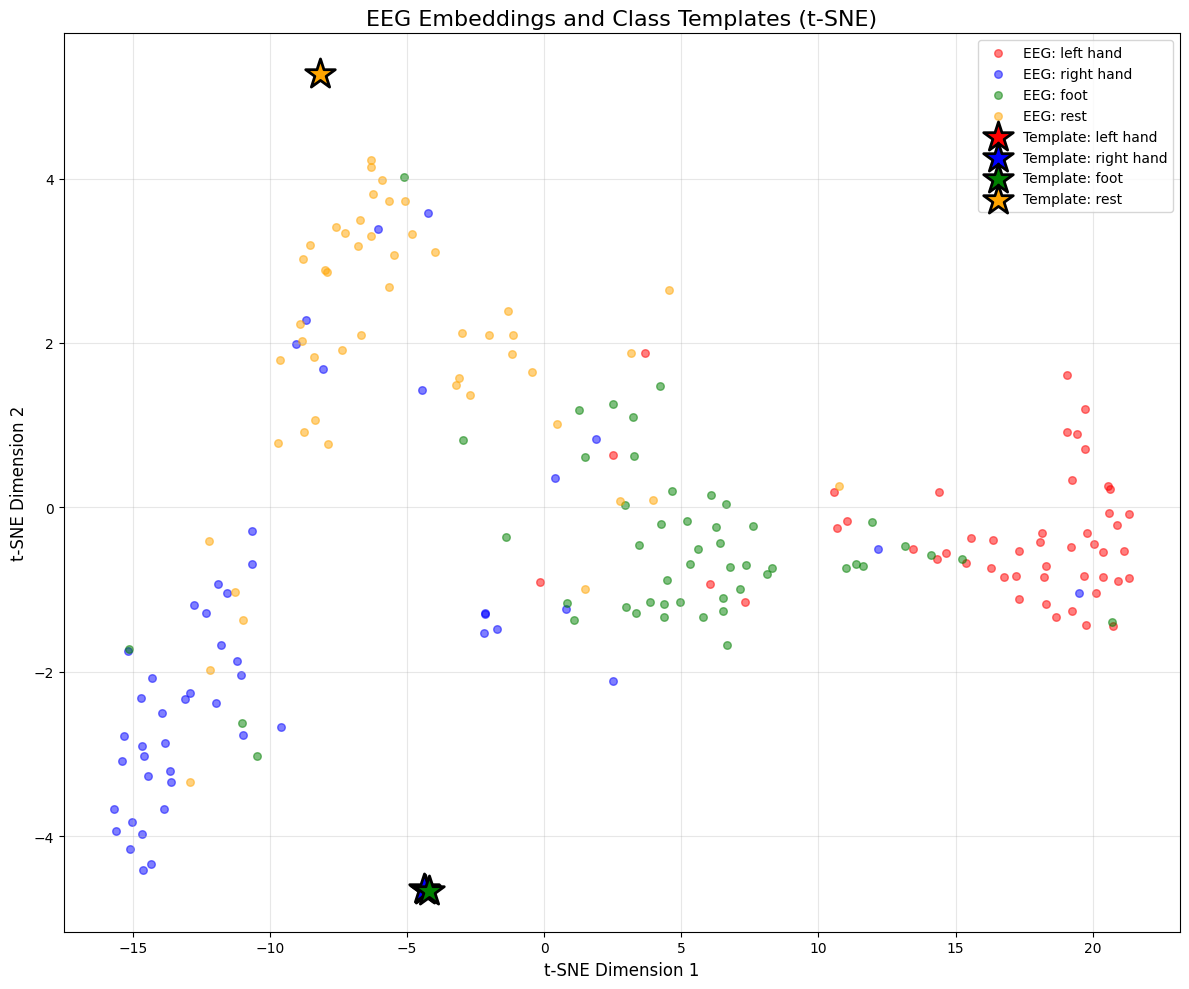


Evaluation complete!


In [13]:
# ============================================================================
# EVALUATION AND VISUALIZATION
# ============================================================================

def plot_confusion_matrix(confusion_matrix, class_names):
    """Plot confusion matrix"""
    import matplotlib.pyplot as plt
    
    # Normalize
    cm = confusion_matrix.numpy()
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix (Normalized)', fontsize=16)
    plt.colorbar()
    
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, f'{cm_normalized[i, j]:.2f}\n({int(cm[i, j])})',
                    ha="center", va="center",
                    color="white" if cm_normalized[i, j] > 0.5 else "black")
    
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


def analyze_per_class_accuracy(confusion_matrix, class_names):
    """Calculate and display per-class accuracy"""
    cm = confusion_matrix.numpy()
    
    print("\n" + "="*80)
    print("PER-CLASS ACCURACY")
    print("="*80)
    
    for i, class_name in enumerate(class_names):
        class_total = cm[i].sum()
        class_correct = cm[i, i]
        class_acc = class_correct / class_total if class_total > 0 else 0
        print(f"{class_name:15s}: {class_acc*100:5.2f}% ({int(class_correct)}/{int(class_total)})")
    
    # Overall accuracy
    total_correct = np.trace(cm)
    total_samples = cm.sum()
    overall_acc = total_correct / total_samples
    print(f"{'Overall':15s}: {overall_acc*100:5.2f}% ({int(total_correct)}/{int(total_samples)})")
    print("="*80)


def visualize_embeddings(model, test_loader, num_samples=200):
    """Visualize EEG and class embeddings in 2D using t-SNE"""
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    
    model.eval()
    
    eeg_embeddings_list = []
    labels_list = []
    
    # Collect embeddings
    with torch.no_grad():
        for eeg_data, labels in test_loader:
            eeg_emb = model.model.eeg_encoder(eeg_data)
            eeg_embeddings_list.append(eeg_emb.cpu())
            labels_list.append(labels.cpu())
            
            if sum(len(l) for l in labels_list) >= num_samples:
                break
    
    # Concatenate
    eeg_embeddings = torch.cat(eeg_embeddings_list, dim=0)[:num_samples]
    labels = torch.cat(labels_list, dim=0)[:num_samples]
    
    # Get class embeddings (first variant of each class)
    class_templates = [
        model.caption_generator.generate_caption(0, 0),
        model.caption_generator.generate_caption(1, 0),
        model.caption_generator.generate_caption(2, 0),
        model.caption_generator.generate_caption(3, 0)
    ]
    class_embeddings = model.model.text_encoder(class_templates).cpu()
    
    # Combine for t-SNE
    all_embeddings = torch.cat([eeg_embeddings, class_embeddings], dim=0)
    
    # Apply t-SNE
    print("\nApplying t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(all_embeddings.numpy())
    
    # Split back
    eeg_2d = embeddings_2d[:num_samples]
    class_2d = embeddings_2d[num_samples:]
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    class_names = ["left hand", "right hand", "foot", "rest"]
    colors = ['red', 'blue', 'green', 'orange']
    
    # Plot EEG embeddings
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        mask = labels == i
        plt.scatter(eeg_2d[mask, 0], eeg_2d[mask, 1], 
                   c=color, label=f'EEG: {class_name}', alpha=0.5, s=30)
    
    # Plot class embeddings as stars
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        plt.scatter(class_2d[i, 0], class_2d[i, 1],
                   c=color, marker='*', s=500, edgecolors='black', linewidths=2,
                   label=f'Template: {class_name}')
    
    plt.title('EEG Embeddings and Class Templates (t-SNE)', fontsize=16)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Run evaluation
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)

class_names = ["left hand", "right hand", "foot", "rest"]

# Confusion matrix
print("\nGenerating confusion matrix...")
confusion = model.val_confusion.compute()
plot_confusion_matrix(confusion, class_names)

# Per-class accuracy
analyze_per_class_accuracy(confusion, class_names)

# Embedding visualization
print("\nGenerating embedding visualization...")
visualize_embeddings(model, val_loader, num_samples=200)

print("\nEvaluation complete!")

# Summary - Batch-wise Contrastive Learning

## Key Innovation

This notebook implements **standard CLIP training** for EEG:

1. **Batch-wise comparison**: Each EEG compared against ALL text captions in batch
2. **Symmetric contrastive loss**: EEG→Text + Text→EEG
3. **Dynamic text encoding**: Captions generated and encoded per batch
4. **Direct embedding architecture**: ATCNet outputs embeddings without bottleneck

## Architecture Comparison

| Aspect | 4-Class Fixed | This Approach (Batch) |
|--------|--------------|------------------------|
| **Text inputs** | 4 fixed templates | batch_size unique captions |
| **Comparison** | EEG vs 4 fixed | EEG vs all batch texts |
| **Label** | Class label (0-3) | Position in batch (0-31) |
| **Random baseline** | 25% (1/4) | ~3.125% (1/32) |
| **Text encoding** | Once at init | Every batch |
| **Loss** | Single direction | Symmetric (both directions) |
| **Task difficulty** | Easier (4 classes) | Harder (fine-grained matching) |

## Training Process

### Each Training Step:
```python
# Input: batch of EEG (32, 1, 50, 1001) + labels (32,)

# Generate unique captions for batch
captions = generate_captions(labels)  # 32 captions

# Encode both modalities
eeg_emb = eeg_encoder(eeg_data)        # (32, 384)
text_emb = text_encoder(captions)      # (32, 384)

# Compute similarity matrix
logits = eeg_emb @ text_emb.T          # (32, 32)

# Symmetric loss
targets = [0, 1, 2, ..., 31]           # Diagonal indices
loss_eeg_to_text = CrossEntropy(logits, targets)
loss_text_to_eeg = CrossEntropy(logits.T, targets)
loss = (loss_eeg_to_text + loss_text_to_eeg) / 2
```

## Metrics

This model tracks TWO types of accuracy:

### 1. Retrieval Accuracy (Batch-level)
- **Task**: Given EEG, find correct caption among batch
- **Baseline**: 1/batch_size (~3.125% for batch=32)
- **Good performance**: 40-60%
- **Excellent**: >60%

### 2. Classification Accuracy (4-class)
- **Task**: Classify EEG into 4 action classes
- **Baseline**: 25% (1/4 classes)
- **Good performance**: 60-80%
- **Excellent**: >80%

## Benefits of Batch-wise Contrastive Learning

### ✅ **Harder Task = Better Representations**
- Model learns fine-grained distinctions
- Forces separation even within same class
- More robust embeddings

### ✅ **Caption Variation**
- Multiple templates per class
- Model learns semantic invariance
- Better generalization to new descriptions

### ✅ **Symmetric Learning**
- Both EEG→Text and Text→EEG directions
- Better alignment between modalities
- More stable training

### ✅ **Scalable**
- Easy to add more classes
- No model architecture change needed
- Just add new caption templates

## Challenges

### ⚠️ **Harder Optimization**
- More negative samples per batch
- Slower convergence than 4-class
- May need more epochs

### ⚠️ **Batch Composition Effects**
- Performance varies with batch composition
- Homogeneous batches (same class) are easier
- Diverse batches are harder but better for learning

### ⚠️ **Computational Cost**
- Text encoding every batch (vs once for 4-class)
- Larger similarity matrix (batch×batch)
- Higher memory usage

## Caption Template Customization

Edit Cell 2 to customize caption styles:

```python
TEMPLATE_STYLE = 'varied'  # Change this!

Options:
- 'simple': Minimal variation ("left hand", "right hand", ...)
- 'varied': Multiple templates per class (6 variants each)
- 'descriptive': Detailed descriptions with context
```

You can also add your own templates in `CaptionGenerator` class!

## Expected Performance

| Metric | Baseline | After 10 epochs | After 50 epochs | Well-trained |
|--------|----------|----------------|-----------------|---------------|
| **Retrieval Acc** | 3.125% | 15-25% | 35-50% | 50-70% |
| **Classification Acc** | 25% | 45-60% | 65-80% | 75-90% |

## When to Use Batch-wise vs 4-Class

### Use Batch-wise (This Approach) If:
- ✅ You want **best possible embeddings**
- ✅ You have **many classes** (>4)
- ✅ You want **retrieval capability**
- ✅ You have **varied text descriptions**
- ✅ You need **fine-grained matching**

### Use 4-Class Fixed If:
- ✅ You have **exactly 4 classes**
- ✅ You want **faster training**
- ✅ You want **simpler optimization**
- ✅ You prioritize **classification accuracy**
- ✅ You have **limited compute**

## Next Steps

1. **Train the model** and compare with 4-class approach
2. **Monitor both metrics**: retrieval and classification accuracy
3. **Experiment with caption templates** to find optimal descriptions
4. **Analyze confusion matrix** for problematic class pairs
5. **Visualize embeddings** to verify proper clustering
6. **Try different batch sizes** (larger = harder negatives)
